In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df= pd.read_csv('customer_segmentation.csv')

In [3]:
df.shape

(2240, 29)

In [5]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012    

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df.describe

<bound method NDFrame.describe of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012  

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df["Frequency"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

In [12]:
monetary_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Monetary"] = df[monetary_cols].sum(axis=1)

In [13]:
rfm = df[["ID", "Recency", "Frequency", "Monetary"]].copy()

rfm.head()

,ID,Recency,Frequency,Monetary
0,5524,58,22,1617
1,2174,38,4,27
2,4141,26,20,776
3,6182,26,6,53
4,5324,94,14,422


In [14]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,2240.000000,2240.000000,2240.000000
mean,49.109375,12.537054,605.798214
std,28.962453,7.205741,602.249288
min,0.000000,0.000000,5.000000
25%,24.000000,6.000000,68.750000
50%,49.000000,12.000000,396.000000
75%,74.000000,18.000000,1045.500000
max,99.000000,32.000000,2525.000000


In [15]:
rfm["AvgPurchaseValue"] = (
    rfm["Monetary"] / rfm["Frequency"].replace(0, np.nan)
)

In [16]:
rfm["AvgPurchaseValue"].describe()

count    2234.000000
mean       38.205823
std        45.929628
min         2.666667
25%        13.000000
50%        29.783333
75%        49.166667
max      1679.000000
Name: AvgPurchaseValue, dtype: float64

In [17]:
rfm.isnull().sum()

ID                  0
Recency             0
Frequency           0
Monetary            0
AvgPurchaseValue    6
dtype: int64

In [18]:
rfm.describe()

,ID,Recency,Frequency,Monetary,AvgPurchaseValue
count,2240.000000,2240.000000,2240.000000,2240.000000,2234.000000
mean,5592.159821,49.109375,12.537054,605.798214,38.205823
std,3246.662198,28.962453,7.205741,602.249288,45.929628
min,0.000000,0.000000,0.000000,5.000000,2.666667
25%,2828.250000,24.000000,6.000000,68.750000,13.000000
50%,5458.500000,49.000000,12.000000,396.000000,29.783333
75%,8427.750000,74.000000,18.000000,1045.500000,49.166667
max,11191.000000,99.000000,32.000000,2525.000000,1679.000000


In [19]:
features = ["Recency", "Frequency", "Monetary"]

X = rfm[features]

In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled[:5]

array([[ 0.30703926,  1.31354426,  1.67941681],
       [-0.38366418, -1.18502179, -0.96127545],
       [-0.79808624,  1.03592581,  0.28267329],
       [-0.79808624, -0.90740334, -0.91809432],
       [ 1.55030546,  0.20307046, -0.30525442]])

In [22]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

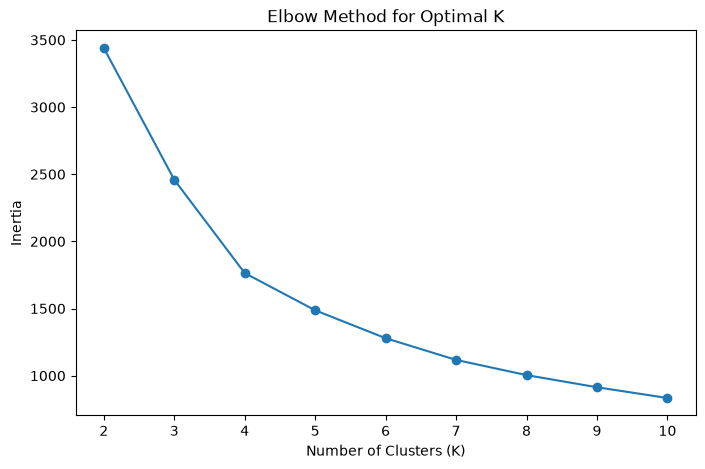

In [23]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

In [26]:
rfm.head()

,ID,Recency,Frequency,Monetary,AvgPurchaseValue,Cluster
0,5524,58,22,1617,73.500000,3
1,2174,38,4,27,6.750000,2
2,4141,26,20,776,38.800000,1
3,6182,26,6,53,8.833333,2
4,5324,94,14,422,30.142857,0


In [27]:
cluster_profile = rfm.groupby("Cluster")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,74.500000,7.064145,148.449013
1,22.950644,19.770386,1184.530043
2,24.433022,7.006231,149.096573
3,73.145038,19.230916,1181.335878


In [28]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

cluster_counts

Cluster
0    608
1    466
2    642
3    524
Name: count, dtype: int64

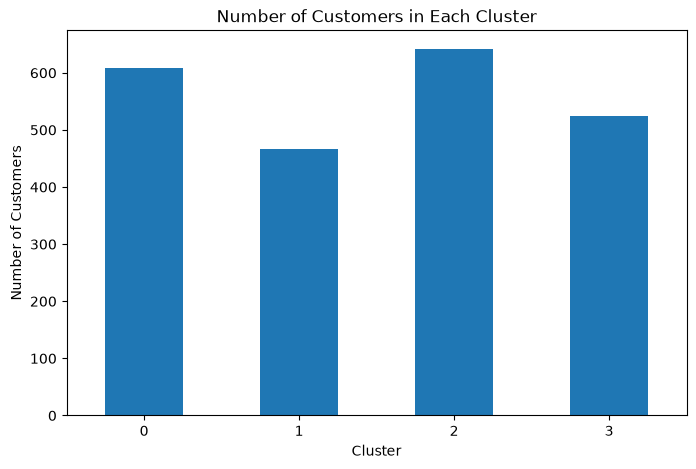

In [29]:
plt.figure(figsize=(8,5))

cluster_counts.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.xticks(rotation=0)

plt.show()

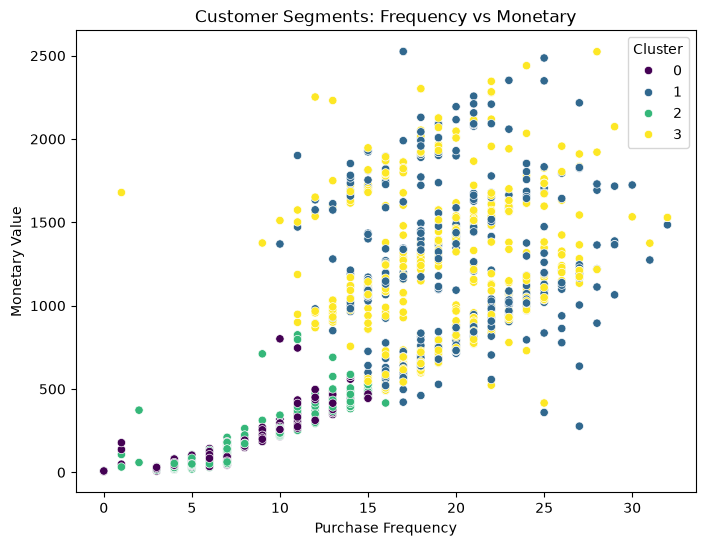

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

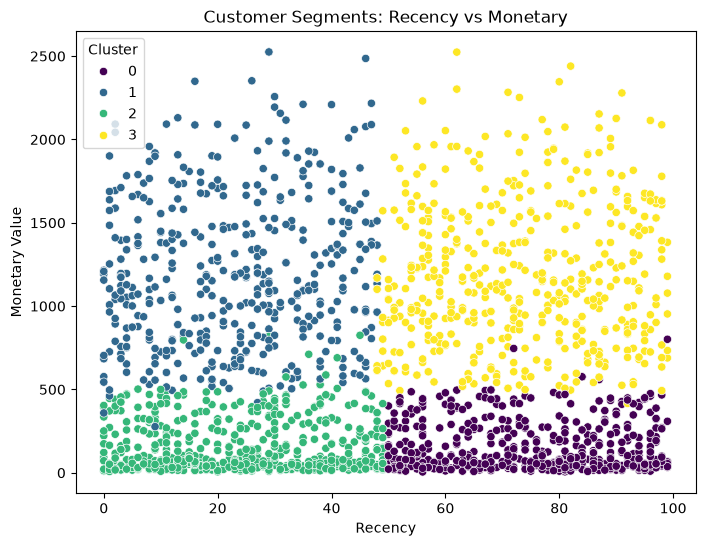

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.show()

In [32]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("ID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,608,74.50,7.06,148.45
1,466,22.95,19.77,1184.53
2,642,24.43,7.01,149.10
3,524,73.15,19.23,1181.34
